In [2]:
%%time

import pandas as pd, numpy as np
import lightgbm as lgb

%load_ext autoreload
%autoreload 2

from warnings import filterwarnings
filterwarnings('ignore')

def vc_method(self):
    return self.value_counts(dropna=False, normalize=True)
pd.Series.vc = vc_method


df = pd.read_parquet('train_sber.parquet')
df['month'] = df.timestamp.dt.month
df['year'] = df.timestamp.dt.year
df['building_age'] = df.year - df.year_of_construction
df.result_price_bin = df.result_price < 6.4
df.head(2)

CPU times: total: 2.16 s
Wall time: 2.11 s


,district_area,road_distance_1,road_distance_2,year_of_construction,bulvar_ring_km,bus_station_distance,cafe_count,fitness_center_distance,floor,district_population,...,sport_count,state,district_name,timestamp,malls_count,railway_station_distance,result_price_bin,month,year,building_age
0,6407578.100,1.422391,3.830951,NaN,13.675657,24.292406,152,0.485841,4.0,86206,...,52,NaN,Bibirevo,2011-08-20,52,14.231961,False,8,2011,NaN
1,9589336.912,2.887377,3.103996,NaN,8.132640,5.706113,177,0.668364,3.0,76284,...,66,NaN,Nagatinskij Zaton,2011-08-23,40,9.242586,False,8,2011,NaN


In [3]:
import lightgbm as lgb

val_date = '2014-09'
print('val percent:', df.timestamp.gt(val_date).mean().round(2))

features = df.columns.drop(['result_price', 'result_price_bin', 'timestamp'])
tr = df.query('timestamp <= @val_date')
val = df.query('timestamp > @val_date')

lgb_tr = lgb.Dataset(tr[features], tr.result_price_bin)
lgb_val = lgb.Dataset(val[features], val.result_price_bin)

X_tr, X_val = tr[features], val[features]
y_tr, y_val = tr.result_price_bin, val.result_price_bin

val percent: 0.19


In [4]:
init_params = {
    'seed': 911,
    'nthread': 16,
    'verbose': -1,
    
    'eta': 0.1,
    'boost_from_average': False, # не работает на кастомных лоссах
    'is_unbalance': False, # не работает на кастомных лоссах
    'scale_pos_weight': 1, # не работает на кастомных лоссах
    
    'objective': 'binary',
    'metric': 'binary_logloss'
}

model_kwargs = {
    'train_set': lgb_tr,
    'valid_sets': [lgb_val],
    'valid_names': ['val'],
    'num_boost_round': 140,
    'callbacks': [lgb.log_evaluation(period=20)]
}

# Кастомные лоссы

**Зачем?**
- асимметричная метрика
- лосс, которого нет в библиотеке
- хитрый учет весов
- лучшее соответствие метрике
- ...

## Уровень 0. LogLoss

### 1. написанный за вас

In [5]:
model = lgb.train(init_params, **model_kwargs)

[20]	val's binary_logloss: 0.238879
[40]	val's binary_logloss: 0.210313
[60]	val's binary_logloss: 0.210305
[80]	val's binary_logloss: 0.21353
[100]	val's binary_logloss: 0.217302
[120]	val's binary_logloss: 0.219637
[140]	val's binary_logloss: 0.221373


### 2. Напишем сами

$$ LogLoss = - y_i \cdot ln(p_i) - (1 - y_i) \cdot ln(1 - p_i) $$
    
$$ p_i = \frac{1}{1 + e^{-y_{raw_i}}} $$

#### 2.1. feval: custom_log_loss

In [6]:
from scipy.special import expit

def custom_log_loss(predictions, tr_data=None, y_true=None, is_custom_objective=False):
    '''
    predictions - raw scores если fobj is not None. Иначе - expit(raw)
    tr_data: lgb.Dataset - train
    
     - веса пока не учитываем
    '''
    # это для того чтобы работать с этой функцией из ноутбука
    if y_true is None:
        y_true = tr_data.get_label()
    y_prob = expit(predictions) if is_custom_objective else predictions
    
    loss = np.zeros(y_prob.shape[0])
    cond = y_true == 0
    loss[cond] = - np.log(1 - y_prob[cond])
    cond = y_true == 1
    loss[cond] = - np.log(y_prob[cond])
    
            # name,          feval_value,   greater_is_better
    return 'custom_log_loss', loss.mean(), False

model = lgb.train(init_params, feval=custom_log_loss, **model_kwargs)

[20]	val's binary_logloss: 0.238879	val's custom_log_loss: 0.238879
[40]	val's binary_logloss: 0.210313	val's custom_log_loss: 0.210313
[60]	val's binary_logloss: 0.210305	val's custom_log_loss: 0.210305
[80]	val's binary_logloss: 0.21353	val's custom_log_loss: 0.21353
[100]	val's binary_logloss: 0.217302	val's custom_log_loss: 0.217302
[120]	val's binary_logloss: 0.219637	val's custom_log_loss: 0.219637
[140]	val's binary_logloss: 0.221373	val's custom_log_loss: 0.221373


#### 2.2 objective: custom_log_loss

In [7]:
def custom_log_loss_grad_hess(y_raw, tr_data=None, y_true=None):
    '''
    gi, hi считаются по w=y_raw, а не по p=expit(raw)
    - веса пока не учитываем
    '''
    if y_true is None:
        y_true = tr_data.get_label()
    y_prob = expit(y_raw)
    
    w = tr_data.get_weight() # VESA
    grad = y_prob - y_true
    hess = y_prob * (1 - y_prob)
    
    return grad, hess



from functools import partial

params = init_params.copy()
params['objective'] = custom_log_loss_grad_hess

model_logloss = lgb.train(
    params,
    feval=partial(custom_log_loss, is_custom_objective=True), # is_custom_objective=True - нужно, когда меняем objective 
#     fobj=custom_log_loss_grad_hess, # Old style
    **model_kwargs
)

[20]	val's binary_logloss: 1.12625	val's custom_log_loss: 0.238879
[40]	val's binary_logloss: 0.889865	val's custom_log_loss: 0.210313
[60]	val's binary_logloss: 0.797836	val's custom_log_loss: 0.210305
[80]	val's binary_logloss: 0.752047	val's custom_log_loss: 0.21353
[100]	val's binary_logloss: 0.742627	val's custom_log_loss: 0.217302
[120]	val's binary_logloss: 0.70412	val's custom_log_loss: 0.219637
[140]	val's binary_logloss: 0.667613	val's custom_log_loss: 0.221373


**Вывод: иногда встроенные метрики работают с кастомными лоссами как-то неправильно - перепроверяйте!**

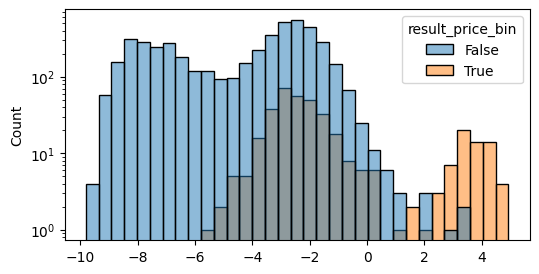

In [8]:
from local_utils import plot_scores

plot_scores(model_logloss, val, features, 'result_price_bin')

## Уровень 1. LogLoss transformations

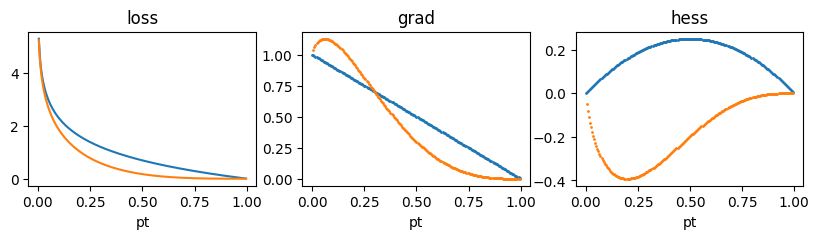

In [9]:
import matplotlib.pyplot as plt

def custom_log_loss_pt(pt):
    '''
    pt - probability of ground truth class
        y_prob, y = 1
        1 - y_prob, otherwise
        
    лосс "на каждом объекте", а не средний
    
    возвращает вектор с пообъектным лоссом для каждого pt_i
    '''
    return - np.log(pt)

def custom_log_loss_grad_hess_pt(pt):
    '''
    pt - probability of ground truth class
        y_prob, y = 1
        1 - y_prob, otherwise
        
    лосс "на каждом объекте", а не средний
    
    возвращает вектор с пообъектным лоссом для каждого pt_i
    '''
    grad = 1 - pt
    hess = pt * (1 - pt)
    return grad, hess

def focal_loss_pt(pt, gamma=0):
    return - ((1 - pt) ** gamma) * np.log(pt)

def focal_loss_grad_hess_pt(pt, y_true, gamma=0):
    y = 2 * y_true - 1  # {0, 1} -> {-1, 1}
    grad = -1 * (1 - pt) ** gamma * (gamma * pt * np.log(pt) + pt - 1)

    u = y * (1 - pt) ** gamma
    du = y * gamma * (1 - pt) ** (gamma - 1)
    v = gamma * pt * np.log(pt) + pt - 1
    dv = gamma * np.log(pt) + gamma + 1
    hess = (du * v + u * dv) * y * (pt * (1 - pt))
    return grad, hess

def plot_loss_grad_hess(feval=None, fobj=None, step=0.005, label=None, ax=None, legend=False, y_true=False):
    pt = np.arange(0, 1, step=step) # probability of ground truth class
    if y_true:
        y = np.random.randint(0, 2, size=pt.shape[0])
        
    if ax is None:
        fig, ax = plt.subplot_mosaic([['loss', 'grad', 'hess']], figsize=(10, 2))

    if feval is not None:
        loss = feval(pt)
        ax['loss'].plot(pt, loss, label=label)
        
    if fobj is not None:
        if not y_true:
            grad, hess = fobj(pt)
        else:
            grad, hess = fobj(pt, y_true=y)
        ax['grad'].scatter(pt, grad, label=label, s=1)
        ax['hess'].scatter(pt, hess, label=label, s=1)

    for key in ['loss', 'grad', 'hess']:
        ax[key].set_title(key)
        ax[key].set_xlabel('pt')
        
    return ax

ax = plot_loss_grad_hess(custom_log_loss_pt, custom_log_loss_grad_hess_pt)

gamma = 2
plot_loss_grad_hess(
    partial(focal_loss_pt, gamma=gamma),
    partial(focal_loss_grad_hess_pt, gamma=gamma),
y_true=True, ax=ax)

plt.plot();

Напоминание:
<font size=5>
$$ w_i  = - \frac{\sum g_i}{\sum h_i + \lambda} $$

**Обучим Focal Loss**

In [15]:
def focal_loss_grad_hess(y_raw, tr, gamma=0):
    y_true = tr.get_label()
    y_prob = np.clip(expit(y_raw), 1e-15, 1 - 1e-15)
    pt = np.where(y_true, y_prob, 1 - y_prob)
    
    y = 2 * y_true - 1  # {0, 1} -> {-1, 1}
    grad = y * (1 - pt) ** gamma * (gamma * pt * np.log(pt) + pt - 1)

    u = y * (1 - pt) ** gamma
    du = y * gamma * (1 - pt) ** (gamma - 1)
    v = gamma * pt * np.log(pt) + pt - 1
    dv = gamma * np.log(pt) + gamma + 1
    hess = (du * v + u * dv) * y * (pt * (1 - pt))
    return grad, hess

def focal_loss(predictions, tr, gamma=0, is_custom_objective=False):
    y_true = tr.get_label()
    y_prob = expit(predictions) if is_custom_objective else predictions
    y_prob = np.clip(y_prob, 1e-15, 1 - 1e-15)
    pt = np.where(y_true, y_prob, 1 - y_prob)
    return 'focal_loss', np.mean(- (1 - pt) ** gamma * np.log(pt)), False

params = init_params.copy()
gamma = 0.
params['objective'] = partial(focal_loss_grad_hess, gamma=gamma)
params['eta'] = 0.1
params['metric'] = 'auc'

model_focal = lgb.train(
    params,
    feval=partial(focal_loss, is_custom_objective=True, gamma=gamma),
    **model_kwargs
)

[20]	val's auc: 0.777915	val's focal_loss: 0.238879
[40]	val's auc: 0.778763	val's focal_loss: 0.210313
[60]	val's auc: 0.772321	val's focal_loss: 0.210305
[80]	val's auc: 0.766658	val's focal_loss: 0.21353
[100]	val's auc: 0.77176	val's focal_loss: 0.217302
[120]	val's auc: 0.769578	val's focal_loss: 0.219637
[140]	val's auc: 0.769264	val's focal_loss: 0.221373


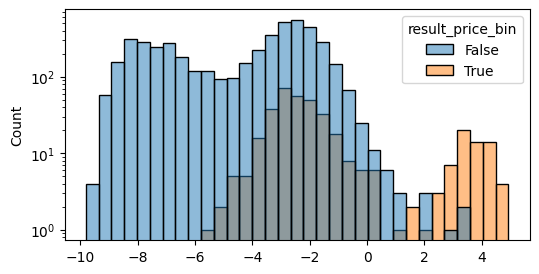

In [16]:
plot_scores(model_focal, val, features, 'result_price_bin', raw_scores=True)

## Уровень 2. Конструируем собственный лосс

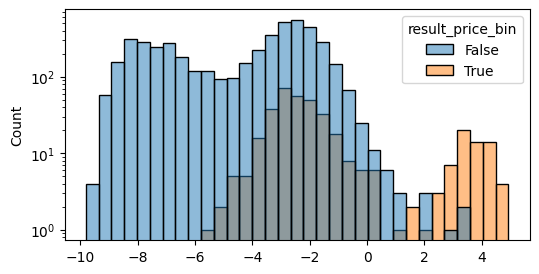

In [17]:
plot_scores(model_logloss, val, features, 'result_price_bin', raw_scores=True)

"Трудная" зона - от -6 до 1. Давайте попробуем улучшить ситуацию с помощью собственного лосса, сделанного специально под это.

In [12]:
expit(-6), expit(1)

(0.0024726231566347743, 0.7310585786300049)

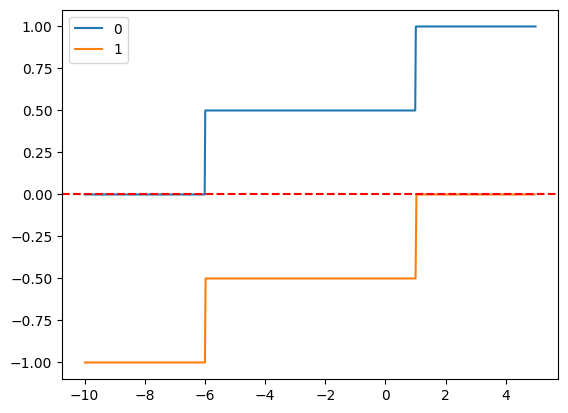

In [19]:
import seaborn as sns

def custom_loss_grad_hess(y_raw, y_true):
    grad = np.zeros_like(y_raw)
    grad[(y_raw > -6) & (y_raw < 1)] = -1/2 * (2 * y_true[(y_raw > -6) & (y_raw < 1)] - 1)
    grad[(y_raw <= -6)] = -y_true[(y_raw <= -6)]
    grad[(y_raw >= 1)] = 1 - y_true[(y_raw >= 1)]

    y_prob = expit(y_raw)
    hess = y_prob * (1 - y_prob)
    return grad, hess

y_raw = np.arange(-10, 5, step=0.01)
y_true = np.random.randint(0, 2, size=y_raw.shape[0])
grad, hess = custom_loss_grad_hess(y_raw, y_true)
sns.lineplot(x=y_raw, y=grad, hue=y_true)
plt.axhline(0, color='red', ls='--')

Чтобы обучить модель на новом лоссе, нужно стартовать со скоров предыдущей модели

In [20]:
def custom_loss_grad_hess_lgb(y_raw, tr):
    y_true = tr.get_label()
    return custom_loss_grad_hess(y_raw, y_true)
    
y_tr_prev = model_logloss.predict(tr[features])
y_val_prev = model_logloss.predict(val[features])

lgb_tr_new = lgb.Dataset(tr[features], tr.result_price_bin, init_score=y_tr_prev)
lgb_val_new = lgb.Dataset(val[features], val.result_price_bin, init_score=y_val_prev)

params = init_params.copy()
params['objective'] = custom_loss_grad_hess_lgb
params['metric'] = 'auc'
params['eta'] = 0.05
params['num_boost_round'] = 200

model_new_kwargs = model_kwargs.copy()
model_new_kwargs['callbacks'] = [lgb.early_stopping(100), lgb.log_evaluation(20)]

model_new = lgb.train(
    params,
    **model_new_kwargs
)

Training until validation scores don't improve for 100 rounds
[20]	val's auc: 0.785589
[40]	val's auc: 0.673923
[60]	val's auc: 0.67611
[80]	val's auc: 0.641497
[100]	val's auc: 0.660628
Early stopping, best iteration is:
[16]	val's auc: 0.786501


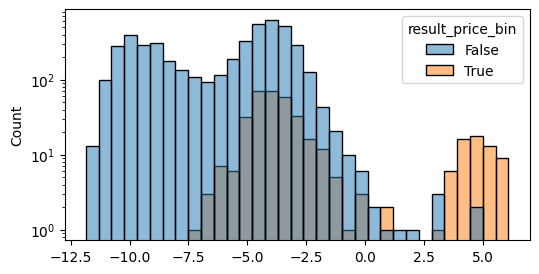

In [25]:
plot_scores(model_new, val, features, 'result_price_bin', init_score=y_val_prev)

**Вывод: не всегда все работает так, как мы этого хотим... не отчаивайтесь! пробуйте!**

### out of scope: [Roc-Star loss](https://github.com/iridiumblue/roc-star) - лосс для рок-аука :)